# ====================================
# Paso 3: RED NEURONAL FEEDFORWARD (FNN)
# ====================================

La **Red Neuronal Feedforward (FNN)**, conocida en la librería Scikit-Learn como **Perceptrón Multicapa (MLPClassifier)**, es el puente exacto entre el Machine Learning Clásico y el Deep Learning.

Una red neuronal tiene tanta capacidad de aprendizaje que podría memorizar cada uno de los 400 viajes en lugar de encontrar los patrones de CO2.

1. **Hiperparámetros vitales (Las palancas de la FNN):** * `hidden_layer_sizes`: Cuántas capas ocultas y neuronas usamos. (Mantendremos redes "pequeñas" para evitar memorizar).
* `alpha`: **El parámetro estrella para la Regularización L2**. Penaliza a la red neuronal si intenta hacer curvas demasiado complejas para separar los datos.
* `activation`: Probaremos `relu` y `tanh`.


2. **Evaluación:** Mantenemos la corona: 80% Entrenamiento (con Stratified K-Fold K=5 para validación interna robusta) y 20% Evaluación ciega final.
3. **Escalado Obligatorio:** Las Redes Neuronales usan derivadas para aprender (Descenso del Gradiente). Si no usamos `StandardScaler`, la red colapsará intentando sumar la Temperatura (25) con el eCo2 (1500).


---



### 1. Importar librerias

In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, ConfusionMatrixDisplay



---


### 2. Montar Google Drive y Cargar

In [ ]:
# 1. Montar Google Drive
drive.mount('/content/drive')

# 2. Definir la ruta donde guardaste los archivos en tu Drive
ruta = "/content/drive/MyDrive/Colab Notebooks/iaic/labF/Resultados/LineaC1_Limpio.csv"

Mounted at /content/drive




---


### 3. Entrenamiento: RED NEURONAL FEEDFORWARD (FNN)

--- MODELO AVANZADO: RED NEURONAL FEEDFORWARD (FNN) ---

Iniciando búsqueda de mejores hiperparámetros...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
✅ Pipeline FNN (Escalador + Modelo) guardado en: /content/drive/MyDrive/Colab Notebooks/iaic/labF/Resultados/pipeline_fnn_final.joblib

--- INFORME DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

       Vacío       0.98      1.00      0.99        46
       Medio       1.00      0.96      0.98        25
       Lleno       1.00      1.00      1.00        10

    accuracy                           0.99        81
   macro avg       0.99      0.99      0.99        81
weighted avg       0.99      0.99      0.99        81



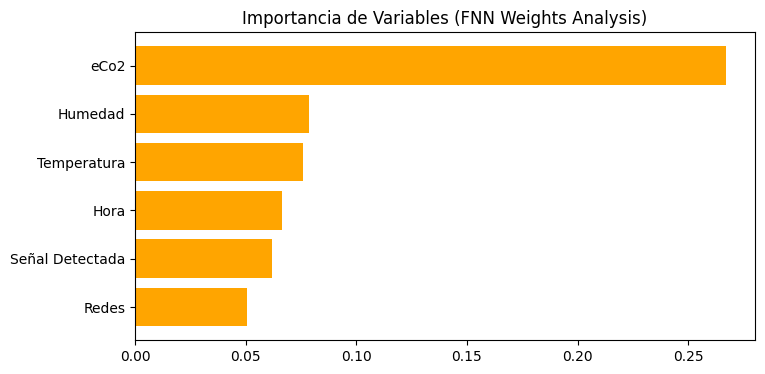

In [ ]:

print("======================================================")
print("--- MODELO AVANZADO: RED NEURONAL FEEDFORWARD (FNN) ---")
print("======================================================\n")

# 1. Carga de datos (Manteniendo tu lógica original)
df = pd.read_csv(ruta).dropna(subset=['TARGET_Aforo'])

X = df[['Temperatura', 'Humedad', 'eCo2', 'Redes', 'Señal Detectada', 'Hora']]
y = df['TARGET_Aforo'].astype(int)

# 2. Partición (Mismo 80/20 y random_state)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# 3. CREACIÓN DEL PIPELINE
# Empaquetamos el Escalador y la Red Neuronal
pipeline_fnn = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(max_iter=2000, random_state=42))
])

# 4. HIPERPARÁMETROS (100% Originales de tu notebook)
param_grid_fnn = {
    'mlp__hidden_layer_sizes': [(32,), (64, 32), (32, 16)],
    'mlp__alpha': [0.0001, 0.01, 0.1, 1.0],
    'mlp__activation': ['relu', 'tanh']
}

# 5. EVALUACIÓN CRUZADA
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search_fnn = GridSearchCV(
    estimator=pipeline_fnn,
    param_grid=param_grid_fnn,
    cv=skf,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

print("Iniciando búsqueda de mejores hiperparámetros...")
grid_search_fnn.fit(X_train, y_train)

# 6. GUARDAR EL PIPELINE COMPLETO
mejor_pipeline_fnn = grid_search_fnn.best_estimator_
ruta_resultados = '/content/drive/MyDrive/Colab Notebooks/iaic/labF/Resultados/'
os.makedirs(ruta_resultados, exist_ok=True)
ruta_archivo_fnn = os.path.join(ruta_resultados, 'pipeline_fnn_final.joblib')

joblib.dump(mejor_pipeline_fnn, ruta_archivo_fnn)
print(f"✅ Pipeline FNN (Escalador + Modelo) guardado en: {ruta_archivo_fnn}")

# 7. EVALUACIÓN Y MÉTRICAS
y_pred = mejor_pipeline_fnn.predict(X_test)
print("\n--- INFORME DE CLASIFICACIÓN ---")
print(classification_report(y_test, y_pred, target_names=['Vacío', 'Medio', 'Lleno']))

# 8. XAI GLOBAL (Importancia basada en Pesos de la primera capa)
# Para MLP no hay 'feature_importances_', calculamos la media absoluta de los pesos
mlp_interno = mejor_pipeline_fnn.named_steps['mlp']
importancias = np.mean(np.abs(mlp_interno.coefs_[0]), axis=1)

df_importancias = pd.DataFrame({'Variable': X.columns, 'Importancia': importancias})
df_importancias = df_importancias.sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(8, 4))
plt.barh(df_importancias['Variable'], df_importancias['Importancia'], color='orange')
plt.gca().invert_yaxis()
plt.title("Importancia de Variables (FNN Weights Analysis)")
plt.show()

---

### 4. Conclusiones

Añadimos el parámetro `alpha` (Regularización) en una Red Neuronal

* Fíjemonos en el `GridSearchCV`: Si elige una arquitectura de `(32,)` (solo una capa) y un `alpha` de `1.0` o `0.1`, el algoritmo nos estará confirmando que, al tener tan pocos datos, está activando todas sus defensas para no sobreajustarse.
* Comparar el **Recall de la clase 'Lleno'**. Si no alcanza el `1.00` perfecto que nos dio el Random Forest, nuestra decisión para el proyecto final debería mantenerse en el **Random Forest**.